In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo
import dorito
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

import equinox
import lineax

print("jax version:", jax.__version__)
print("zodiax version:", zodiax.__version__)
print("amigo version:", amigo.__version__)
print("dorito version:", dorito.__version__)

print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)

NVIDIA H200
jax version: 0.8.3
zodiax version: 0.4.1
amigo version: 0.0.10
dorito version: 0.2.0
equinox version: 0.13.6
lineax version 0.1.0


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(gethostname())

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/code/dorito_notebooks/files/outputs/retrain"

elif gethostname().startswith("max-test-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    output_path = "/home/dgxuser/max/code/dorito_notebooks/files/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# dealing with saving figures when running in script


def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


save_flag = check_script()

if save_flag:
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    if job_id is None:
        job_id = "local"
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    print(f"Save path: {save_path}")
else:
    save_path = None

print(amigo_files_path)

max-test-0-12
Running in a notebook or interactive shell
/home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Validation files
Calibrators from other science programs

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []


# 1093, Deepashri Thatte
program_path = os.path.join(data_dir, "1093/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] == "HD-36805"]
val_files += files

# 1843, Jens Kammerer
program_path = os.path.join(data_dir, "1843/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
val_files += files

# 1242, Doug Johnstone
program_path = os.path.join(data_dir, "1242/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] != "TD-CAL-HD-101531"]
val_files += files

# Creating a subset of the data for testing
_ = []
filts = []
for file in val_files:
    filt = file[0].header["FILTER"]
    if filt not in filts:
        _.append(file)
        filts.append(filt)
val_files = _

# Adding bad pixels and summarising metadata
val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

  program    target filter dither    g/i        date                 PI   CAL
0    1093  HD-36805  F430M    2/2   6/82  23-05-2022  Thatte, Deepashri  True
1    1093  HD-36805  F380M    1/1  3/122  05-06-2022  Thatte, Deepashri  True
2    1093  HD-36805  F480M  11/25   9/65  05-06-2022  Thatte, Deepashri  True


## Calibration files
The main training data, including flats.

In [5]:
calpsf_files = []
calbin_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
calpsf_files += files

print()
print("CAL8330 - Benjamin Pope")
program_path = os.path.join(data_dir, "8330/calslope/")
files = get_files(program_path, "nis_calslope")
calbin_files += files

# Creating a subset of the data for testing
_ = []
filts = []
for file in calpsf_files:
    filt = file[0].header["FILTER"]
    if filt not in filts:
        _.append(file)
        filts.append(filt)
calpsf_files = _

calpsf_files = [add_badpix(file) for file in calpsf_files]
summarise_files(calpsf_files)

# Creating a subset of the data for testing
_ = []
filts = []
for file in calbin_files:
    filt = file[0].header["FILTER"]
    if filt not in filts:
        _.append(file)
        filts.append(filt)
calbin_files = _

calbin_files = [add_badpix(file) for file in calbin_files]
summarise_files(calbin_files)

CAL4481 - Anand Sivaramakrishnan

CAL8330 - Benjamin Pope
  program    target filter dither      g/i        date                       PI   CAL
0    4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1    4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
2    4481  HD-41094  F430M    2/5   20/905  05-05-2024  Sivaramakrishnan, Anand  True
  program    target filter dither     g/i        date              PI    CAL
0    8330  V-EZ-Aqr  F380M   9/10  11/260  11-11-2025  Pope, Benjamin  False
1    8330  V-EZ-Aqr  F430M   4/10  16/250  11-11-2025  Pope, Benjamin  False
2    8330  V-EZ-Aqr  F480M   5/10   3/325  11-11-2025  Pope, Benjamin  False


Flats.

In [6]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files

# Creating a subset of the data for testing
flat_files = flat_files[-4:]

flat_files = [
    add_badpix(file) for file in flat_files if file[0].header["NGROUPS"] != 45  # Louis
]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    4472  UNKNOWN  F356W    1/1  20/10  29-04-2024  Martel, Andre  FLAT
1    6654  UNKNOWN  CLEAR    1/1  10/11  22-07-2024  Martel, Andre  FLAT
2    6654  UNKNOWN  F430M    1/1  30/10  27-07-2024  Martel, Andre  FLAT


# Exposures

In [7]:
from amigo.model_fits import PointFit, FlatFit
from retrain_fns import BinaryFit


# Construct the exposures
flat_exposures = [FlatFit(file) for file in flat_files[0:1]]
# flat_exposures = [FlatFit(file) for file in flat_files]
val_exposures = [PointFit(file) for file in val_files[0:1]]
# val_exposures = [PointFit(file) for file in val_files]
calpsf_exposures = [PointFit(file) for file in calpsf_files[2:3]]
# calpsf_exposures = [PointFit(file) for file in cal_files]
calbin_exposures = [BinaryFit(file) for file in calbin_files[0:1]]
# calbin_exposures = [BinaryFit(file) for file in calbin_files

cal_exposures = calbin_exposures + calpsf_exposures
exposures = calpsf_exposures + calbin_exposures + flat_exposures + val_exposures

# # just closing the files
# files = calpsf_files + calbin_files + val_files + flat_files
# _ = [f.close() for f in files]

Finally, let's batch the exposures for training.

In [8]:
from amigo.fitting import batch_exposures

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=1, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=1, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=1, key="val")
batches = {**cal_batch, **flat_batch}

# Building model

In [9]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    # optics=AMIOptics(),
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    # state=load_dict(amigo_files_path + "/calibration.npy"),
)

('08330_002_0C_03_5', Array([ 0.36114405, -0.03072847], dtype=float64))
('V-EZ-Aqr_F480M', Array([0., 0.], dtype=float64))


Populate from state.

In [10]:
state = load_dict(amigo_files_path + "/calibration.npy")
print(state.keys())

for key, value in state.items():
    if key in ["positions", "fluxes", "aberrations"]: #, "nn_weights"]:
        continue
    if key in ["transmission", "badpix"]:
        continue
    model = model.set(key, value)

ab_dict = {}
for key, _ in model.aberrations.items():
    prog, filt = key.split("_")
    ab_dict[key] = state["aberrations"][filt]

model = model.set("aberrations", ab_dict)


# initial normalisations
ff = model.FF
ff -= np.median(ff) - 1.
ff = ff.at[badpix].set(1.)
model = model.set("FF", ff)

non_lin = model.non_linearity.at[:, badpix].set(0)
model = model.set("non_linearity", non_lin)

for exp in calbin_exposures:
    model = model.set(exp.map_param("pas"), np.array(78.,))
    model = model.set(exp.map_param("separations"), np.array(0.123,))
    model = model.set(exp.map_param("contrasts"), np.array(0.376,))

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix'])


## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

In [11]:
from amigo.plotting import summarise_fit

plot_flag = False

if plot_flag:
    done = []
    for exp in cal_exposures:
        # if exp.filter in done:
        #     continue
        print(exp.filter)
        exp.print_summary()
        summarise_fit(model, exp, save_path=save_path)
        done.append(exp.filter)

Now the validator exposures.

In [12]:
if plot_flag:
    done = []
    for exp in val_exposures:
        if exp.filter in done:
            continue
        print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
        summarise_fit(model, exp, save_path=save_path)
        done.append(exp.filter)

Finally, the flats.

In [13]:
if plot_flag:
    for exp in flat_exposures:
        print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
        summarise_fit(model, exp, save_path=save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [14]:
from retrain_fns import (
    loss_fn,
    args_fn,
    looper_fn,
    grads_fn,
    aux_fn,
    ff_reg,
    nl_reg,
    temp_decay,
    cosine_warmup,
)

def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    return model_params, args


# REGULARISATION
reg_dict = {
    "FF": (1., ff_reg),
    "NL": (1., nl_reg),
}

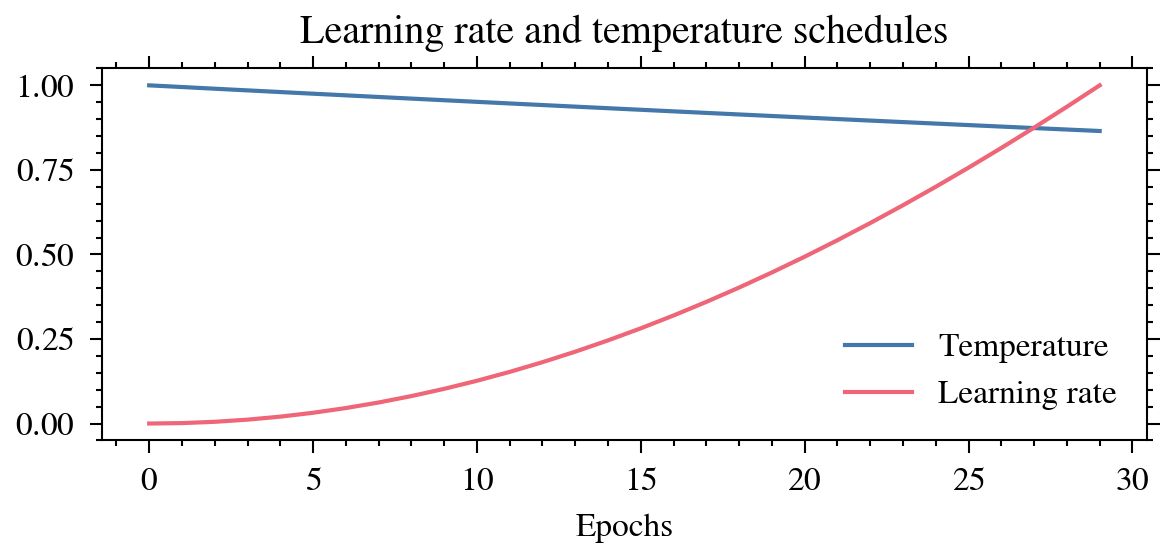

In [15]:
epochs = 30
n_batch = len(batches)

# WARM UP
max_lr = 1.0  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 1e-6  # Initial temperature
decay = 0.005  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "l2": np.array(0.0),
    "max_lr": np.array(max_lr),  # Learning rate after warm up
    "reg_dict": reg_dict,
}

ts = np.arange(epochs)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
l2s = 0 * cosine_warmup(ts, 0, 1000)
args = {**args, **{"l2_schedule": l2s}}


plt.figure(figsize=(4, 2))
plt.title("Learning rate and temperature schedules")
plt.plot(ts, temps / temps.max(), label="Temperature")
plt.plot(ts, lrs / lrs.max(), label="Learning rate")
# plt.plot(ts, l2s / l2s.max(), "--", label="L2 schedule")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [16]:
from amigo.calibration import ValBatchedTrainer  #, looper_fn, Trainer, aux_fn

recalculate_flag = False

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
# trainer = Trainer(
trainer = ValBatchedTrainer(
    loss_fn,
    args_fn=args_fn,
    looper_fn=looper_fn,
    grad_fn=grads_fn,
    norm_fn=norm_fn,
    aux_fn=aux_fn,
    cache=cache_dir,
)

trainer = trainer.update_fishers(
    linear_model,
    flat_exposures,
    parameters=["flat_coeffs", "fluxes"],
    recalculate=recalculate_flag,
)

trainer = trainer.update_fishers(
    linear_model,
    val_exposures,
    batch_size=20,
    parameters=["positions", "aberrations", "fluxes", "spectra"],
    recalculate=recalculate_flag,
)


trainer = trainer.update_fishers(
    linear_model,
    cal_exposures,
    batch_size=20,
    parameters=["distortion", "defocus", "aberrations", "primary_beam"],
    recalculate=recalculate_flag,
)


trainer = trainer.update_fishers(
    linear_model,
    cal_exposures,
    parameters=[
        "positions",
        "fluxes",
        "spectra",
        "jitter",
        "dark_current",
        "SRF",
    ],
    recalculate=recalculate_flag,
)

trainer = trainer.update_fishers(
    linear_model,
    calbin_exposures,
    parameters=[
        "pas",
        "separations",
        "contrasts",
    ],
    # recalculate=True,
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Training.

In [17]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "fluxes": sgd(1e-3, 0),
    "flat_coeffs": sgd(5e-3, 0),
    "positions": sgd(1e-3, 2),
    "aberrations": sgd(1e-3, 5),
    "pas": sgd(1e-3, 5),
    "separations": sgd(5e-3, 7),
    "contrasts": sgd(5e-3, 8),
    "nn_weights": adam(1e-4, 10),  # lr applied with warm up
    "jitter": sgd(2e-3, 15),  # start at 50th?
    "defocus": sgd(2e-3, 25),
    "distortion": sgd(2e-3, 30),
    "dark_current": sgd(2e-3, 35),
    "primary_beam": sgd(2e-4, 40),
    "non_linearity": sgd(1e-4, 100),
    "spectra": sgd(1e-3, 100),
    "FF": sgd(2e-4, 150),
    "SRF": sgd(2e-3, 250),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jtu.map(fn, model)

# Train the model
# with jax.disable_jit():
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    # batches=cal_exposures,
    batches={**cal_batch, **flat_batch},
    validators=val_batch,
    batched_params=["nn_weights"],
    validator_params=["positions", "fluxes", "aberrations", "spectra"],
    args=args,
)

  0%|          | 0/30 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...
Compiling Loss function...
Compiling Loss function...
Compiling Loss function...
Compiling update function...
Compile time: 0:01:27

Initial_loss Loss: 184.97
Compiling Loss function...
Estimated run time: 0:10:49
Full Time: 0:00:59
Final Loss: 16.20


Plotting the results of that fit!

In [18]:
# Unwrapping into cal, val, and flat
aux_history = jtu.map(
    lambda x: np.array(x), result.aux, is_leaf=lambda x: isinstance(x, list)
)

cal, val, flat = [], [], []
for (batch_key, exp_key), value in aux_history["loglike"].items():
    if "cal" in batch_key:
        cal.append(value)
    if "val" in batch_key:
        val.append(value)
    if "flat" in batch_key:
        flat.append(value)
cal = np.array(cal)
val = np.array(val)
flat = np.array(flat)

# Finding BEST STATE from the fit
mean_val = np.array(val).mean(0)  # mean loss for validators
best = mean_val.min()  # best state is where the validator loss was minimum
idx = np.where(mean_val == best)[0][0]
test_aux = jtu.map(
    lambda x: x[: idx + 1], result.aux, is_leaf=lambda x: isinstance(x, list)
)
print(f"Best: {idx}")
print(looper_fn(result.losses, test_aux))

Best: 29
Cal: 21.94 Δ -0.09 | Val: 7.00 Δ -0.07 | Flat: 17.76 Δ -0.07 | Prior: -0.96 Δ 0.00


(29,)


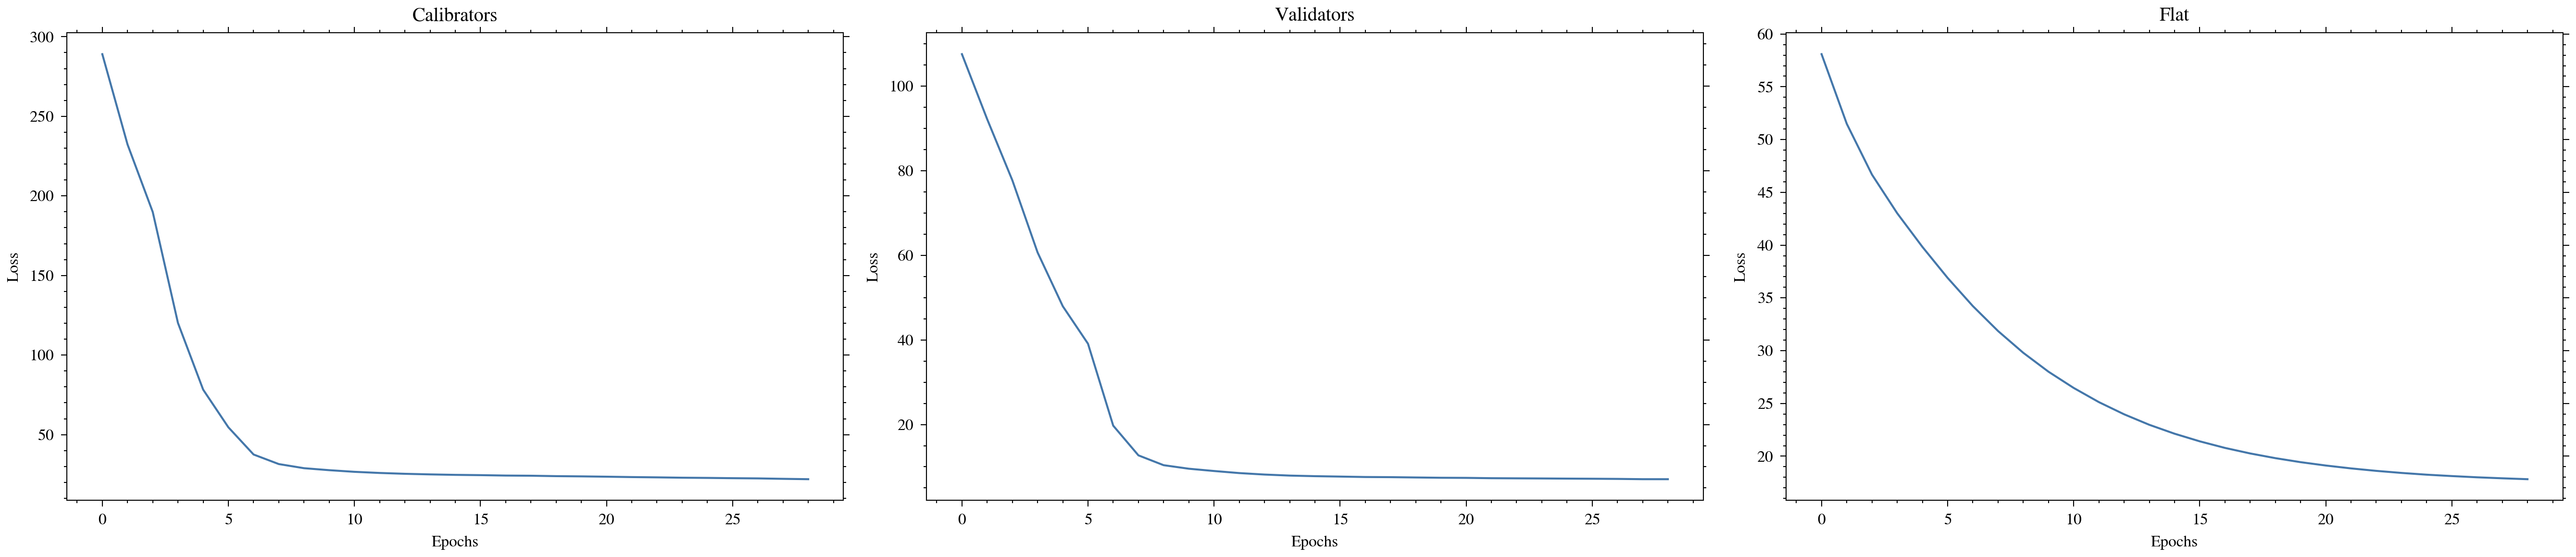

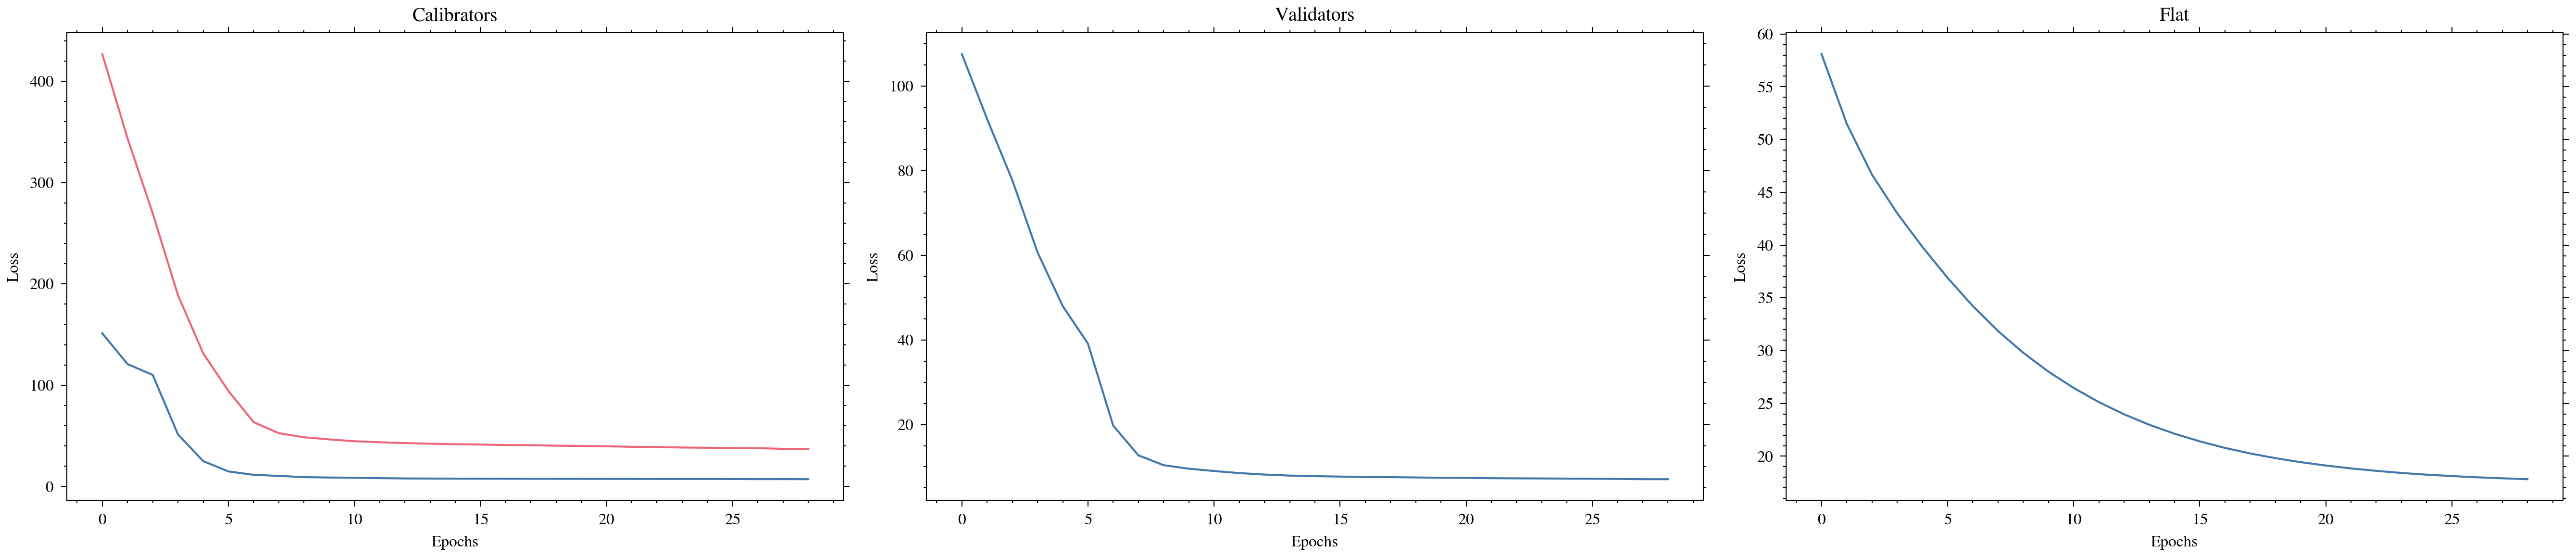

In [19]:
#
# epochs = cal.shape[-1]
# start, stop = 500, -1
start, stop = 0, -1


if stop < 0:
    stop = cal.shape[-1] + stop
xs = np.arange(start, stop)

print(np.array(cal).mean(0)[xs].shape)

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
plt.plot(xs, np.array(cal).mean(0)[xs])
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(val).mean(0)[xs])

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
plt.plot(xs, np.array(flat).mean(0)[xs])

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "mean_losses.png"), dpi=200)
    plt.close()
else:
    plt.show()

###

plt.figure(figsize=(18, 4))
ax = plt.subplot(1, 3, 1)
ax.set(title="Calibrators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in cal]

ax = plt.subplot(1, 3, 2)
ax.set(title="Validators", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in val]

ax = plt.subplot(1, 3, 3)
ax.set(title="Flat", xlabel="Epochs", ylabel="Loss")
[plt.plot(xs, ys[xs]) for ys in flat]

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "all_losses.png"), dpi=200)
    plt.close()
else:
    plt.show()

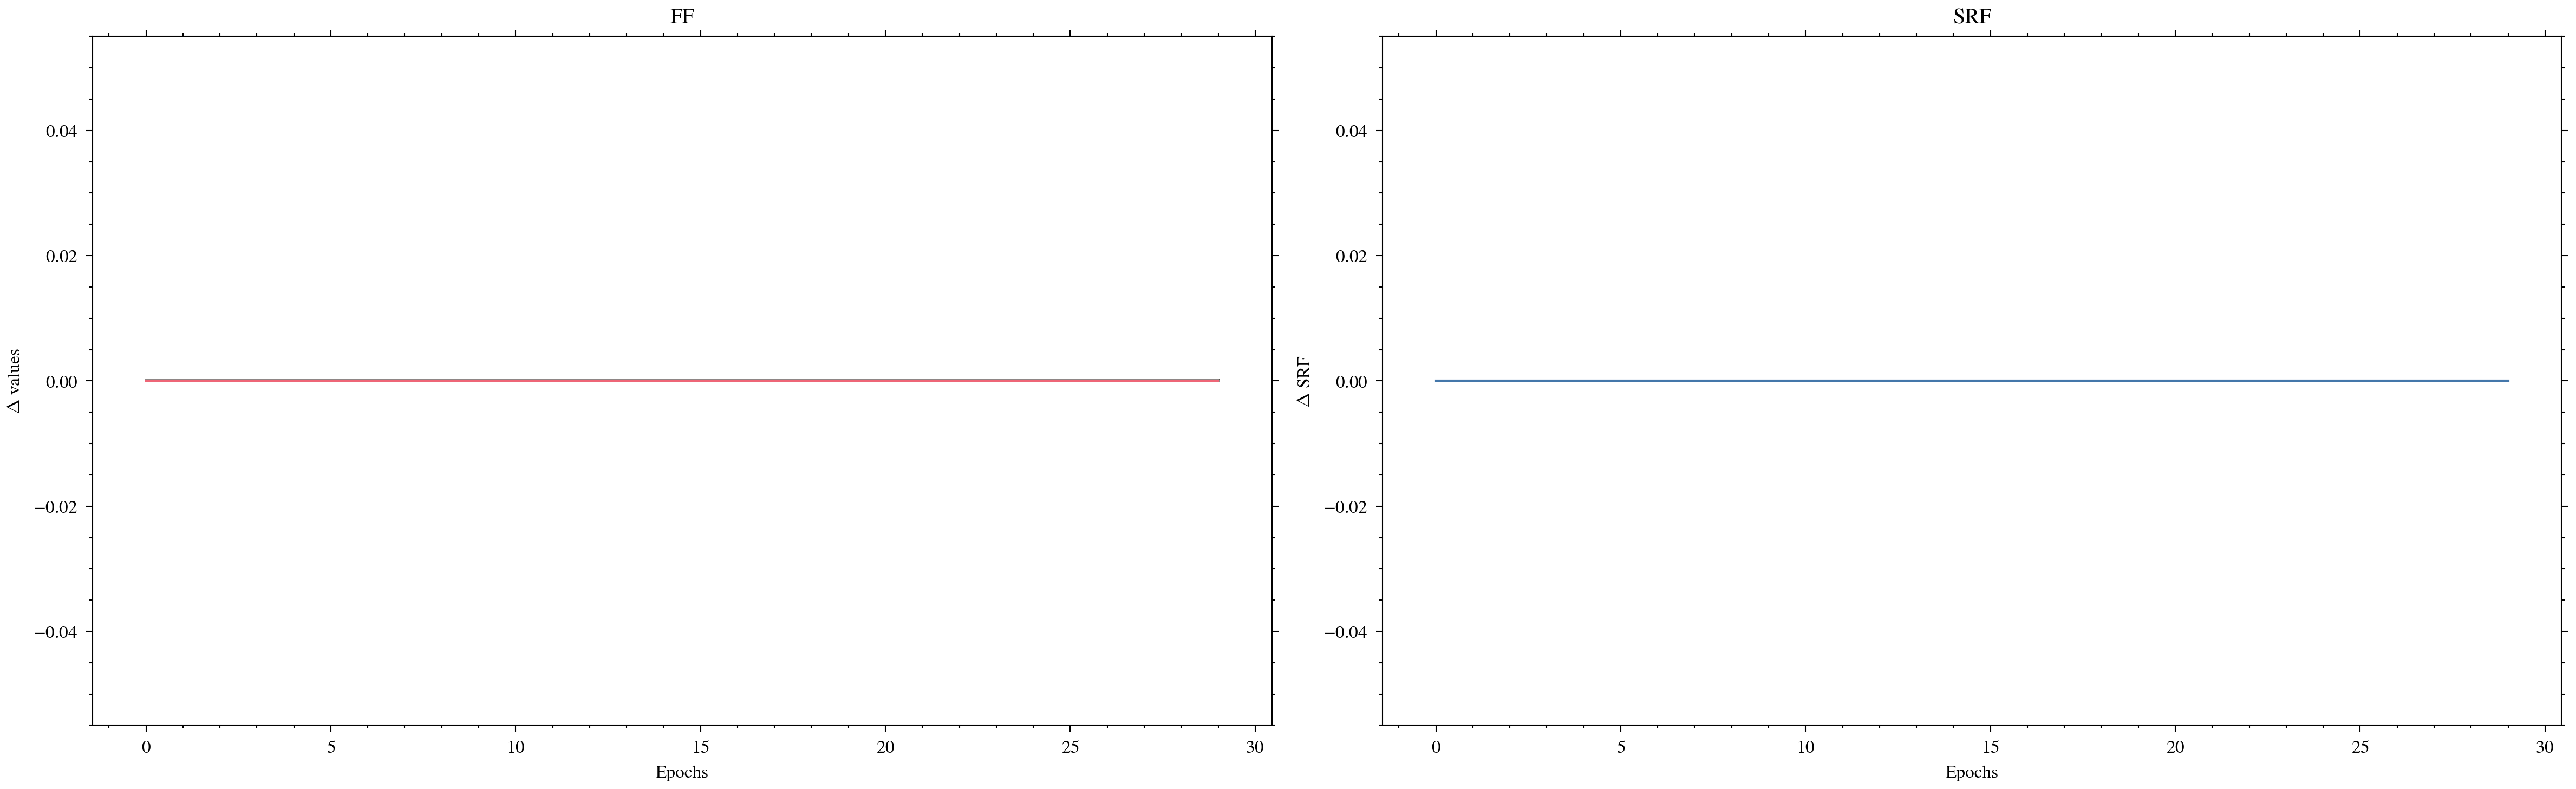

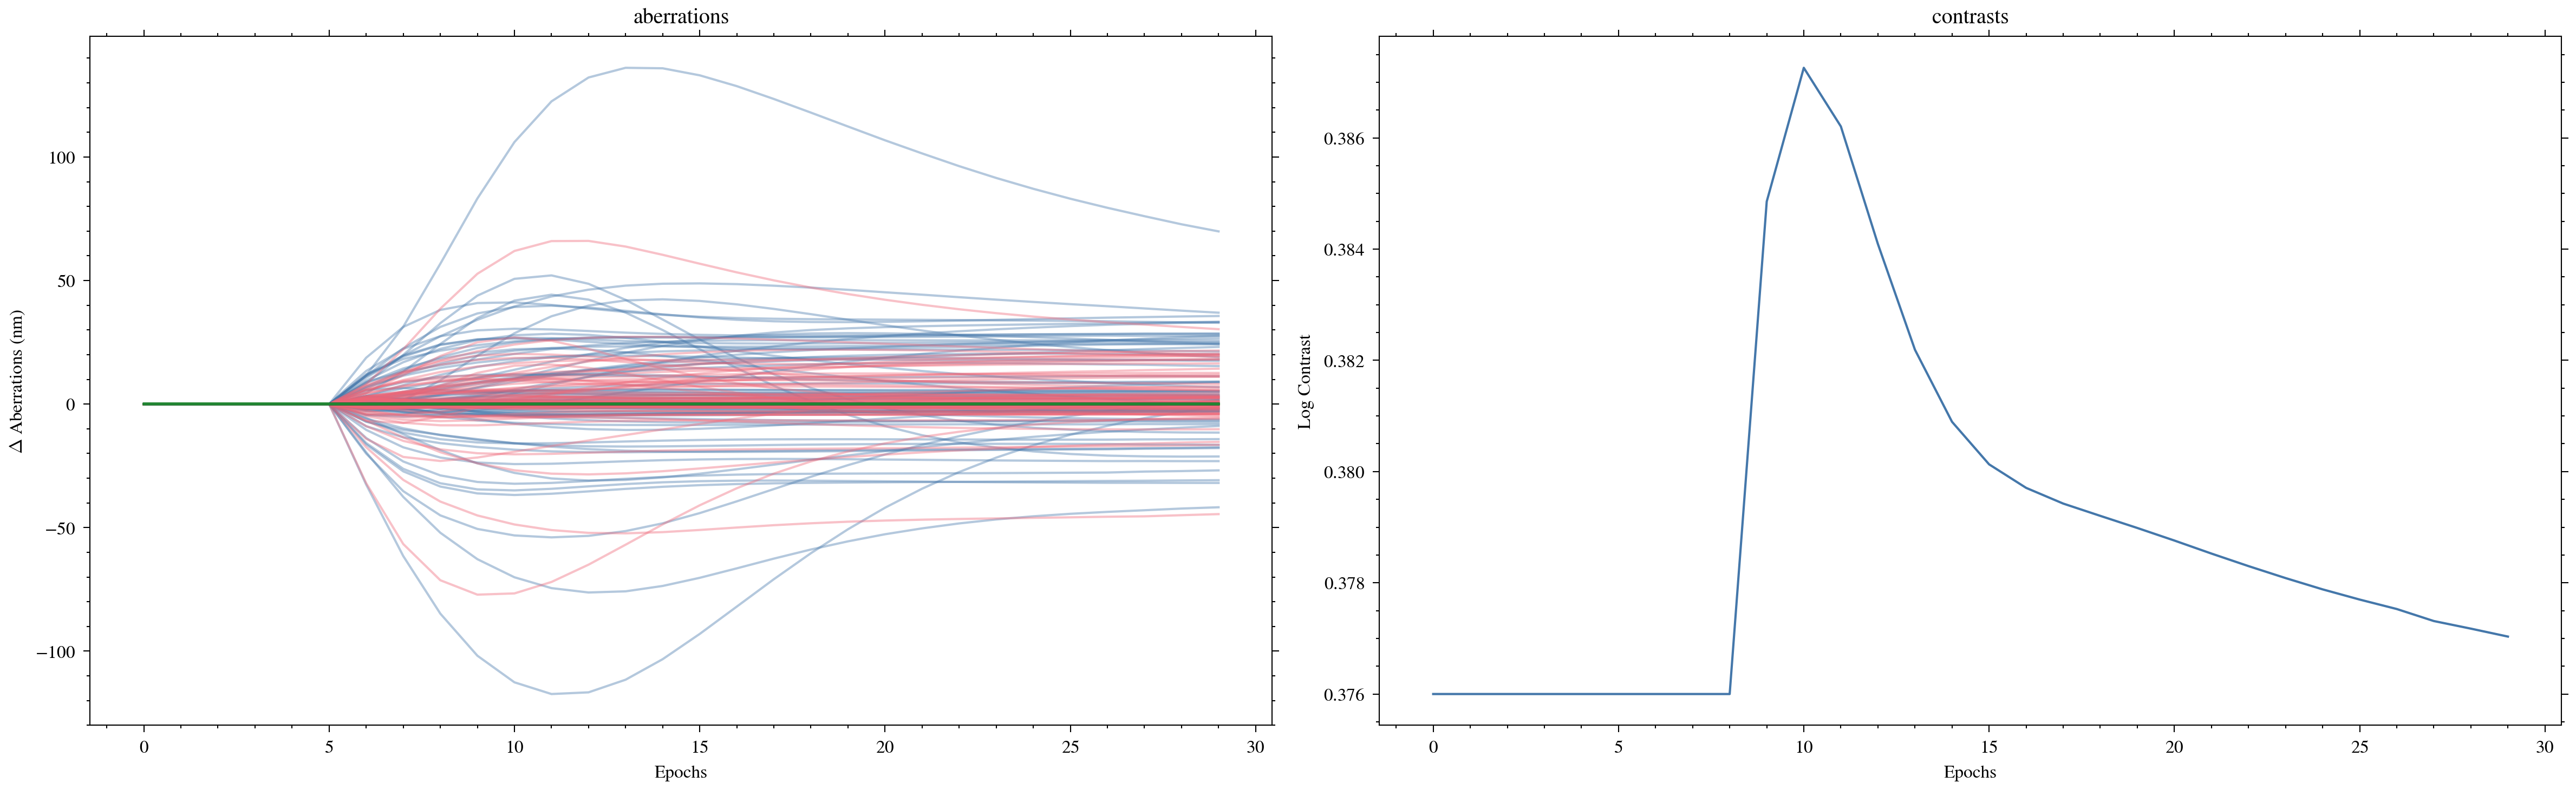

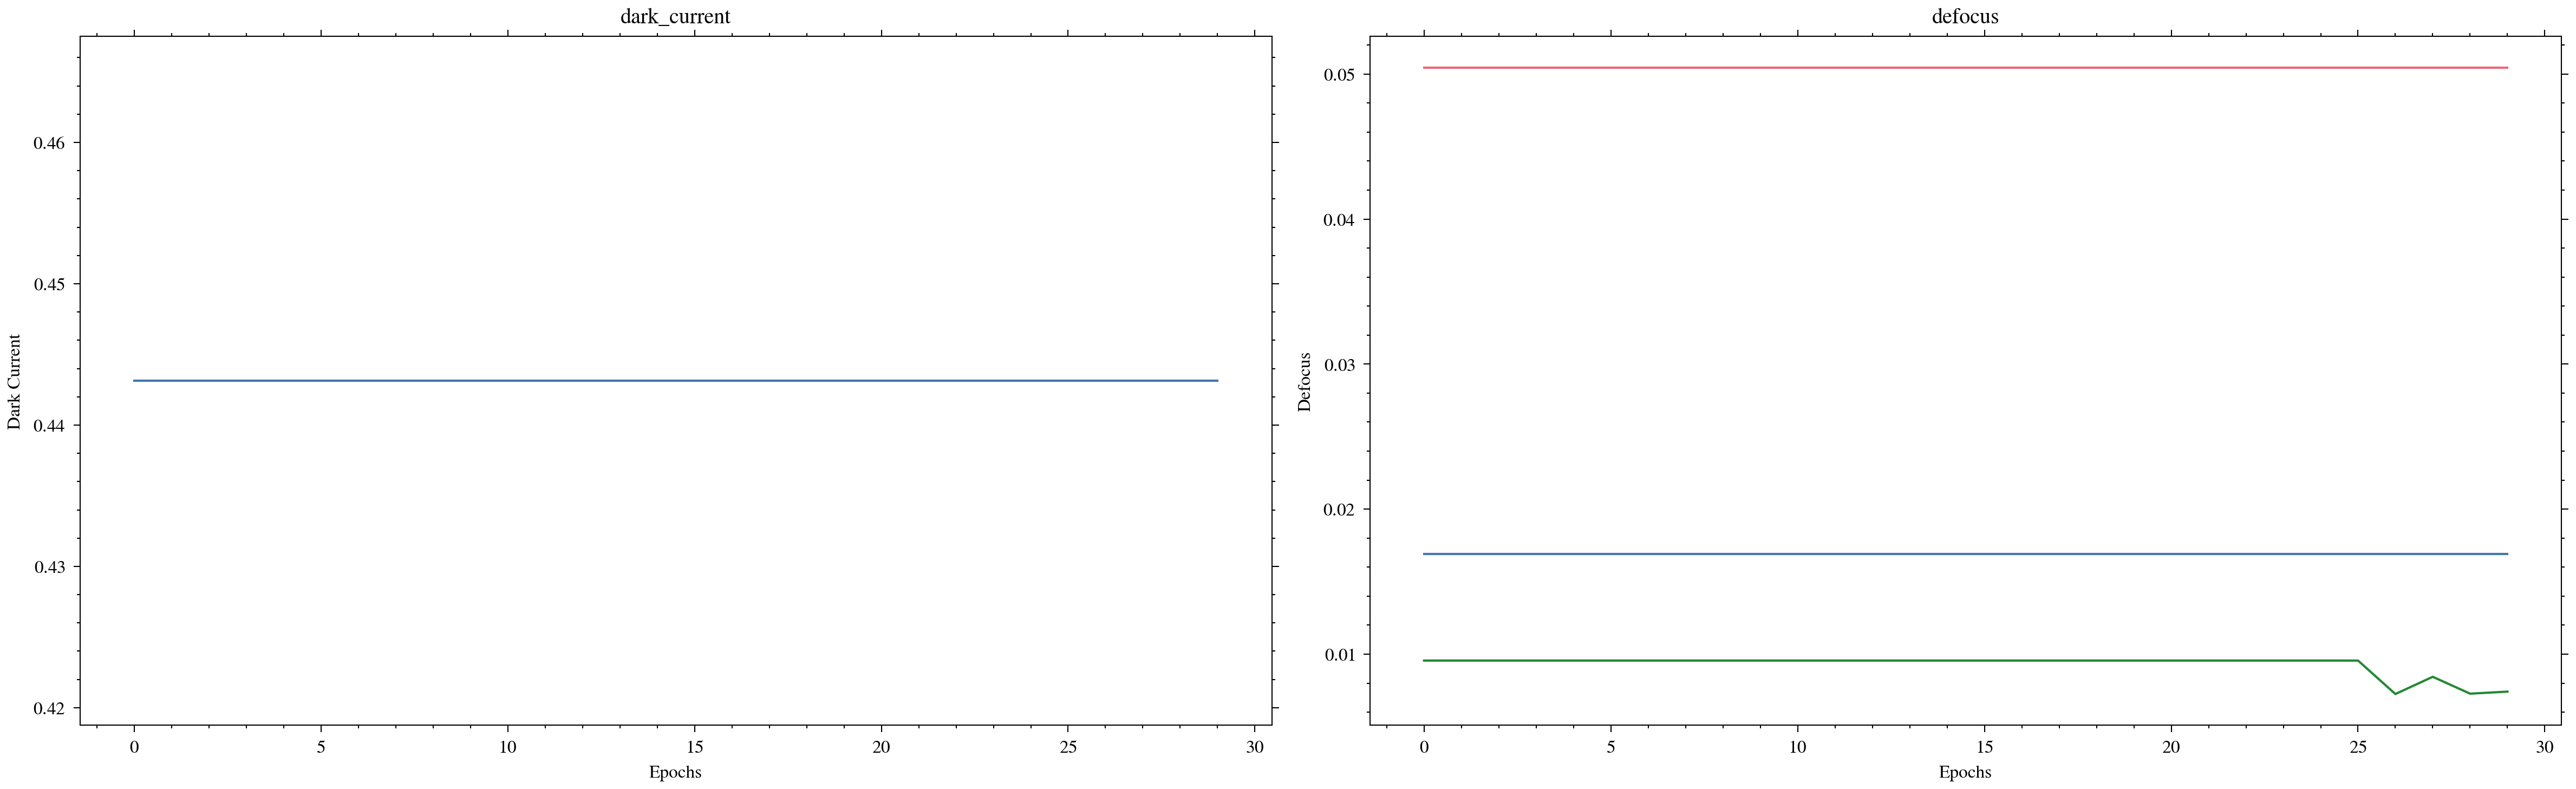

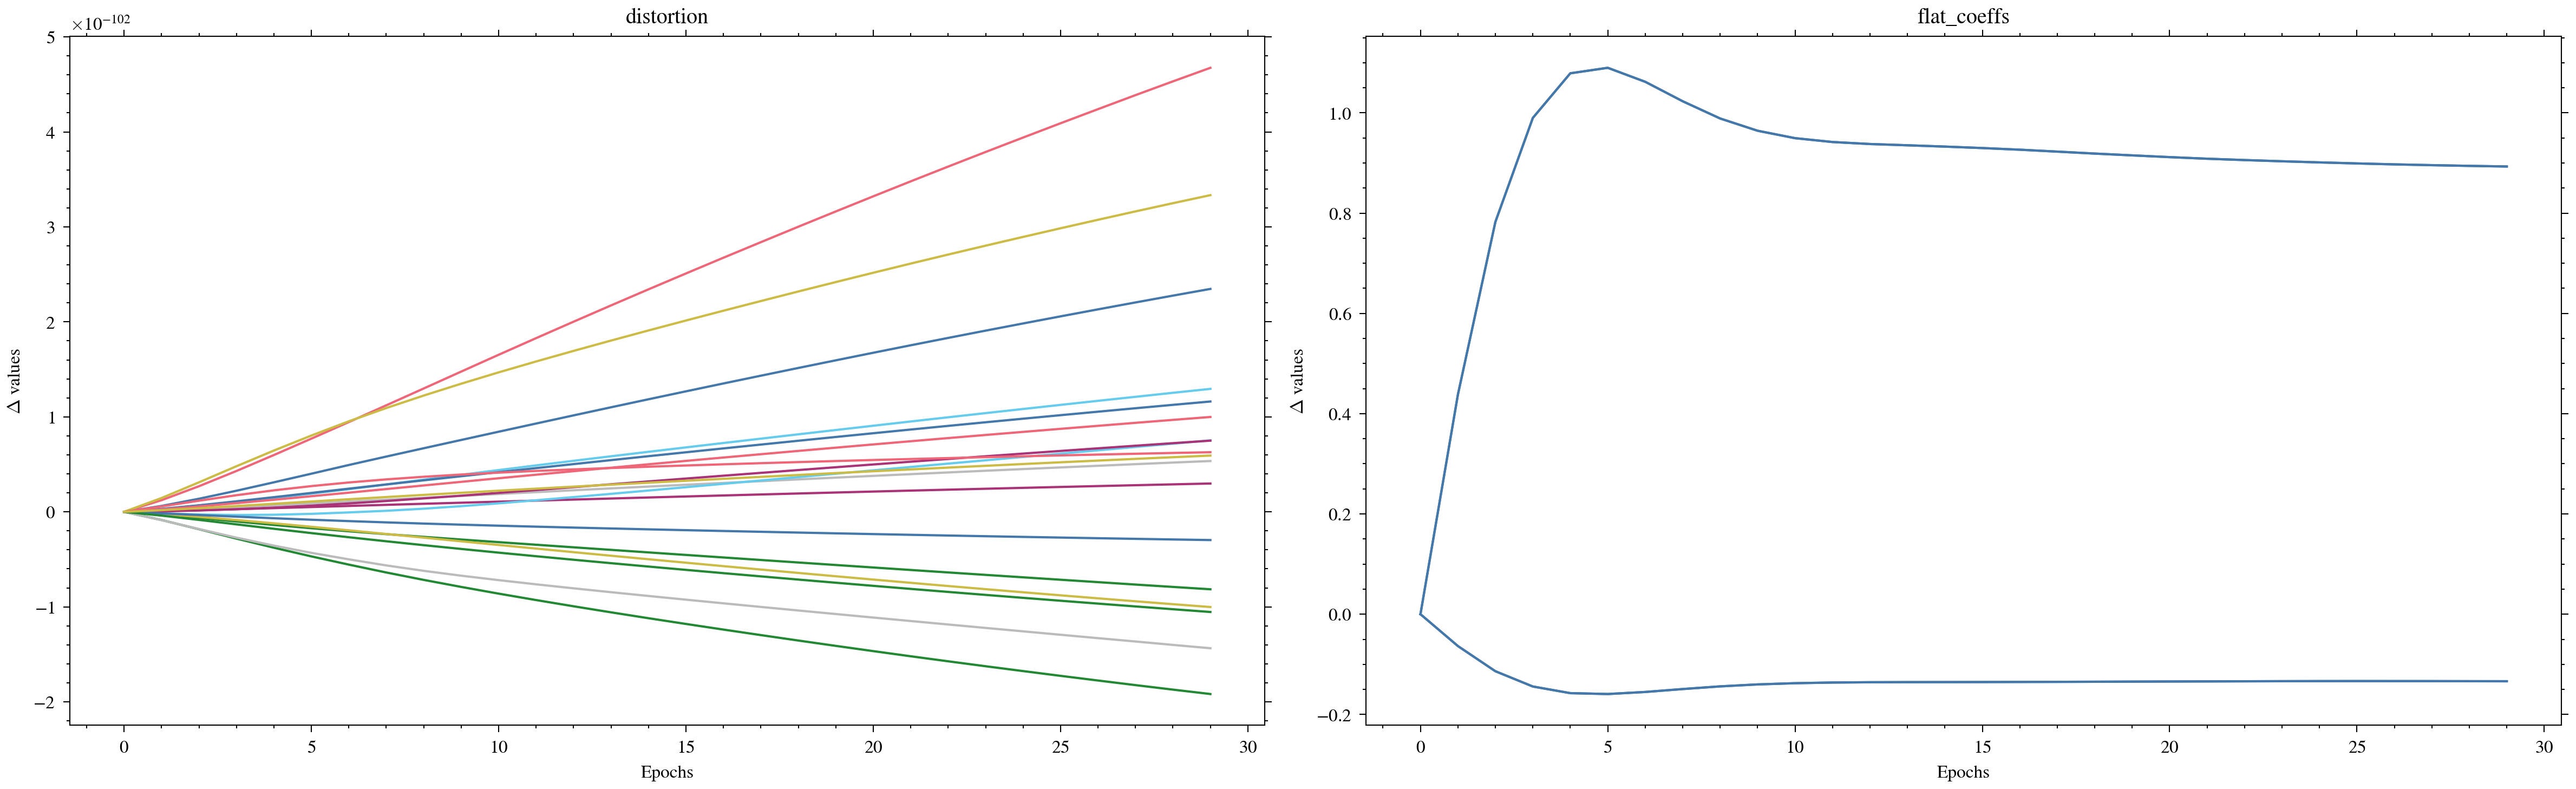

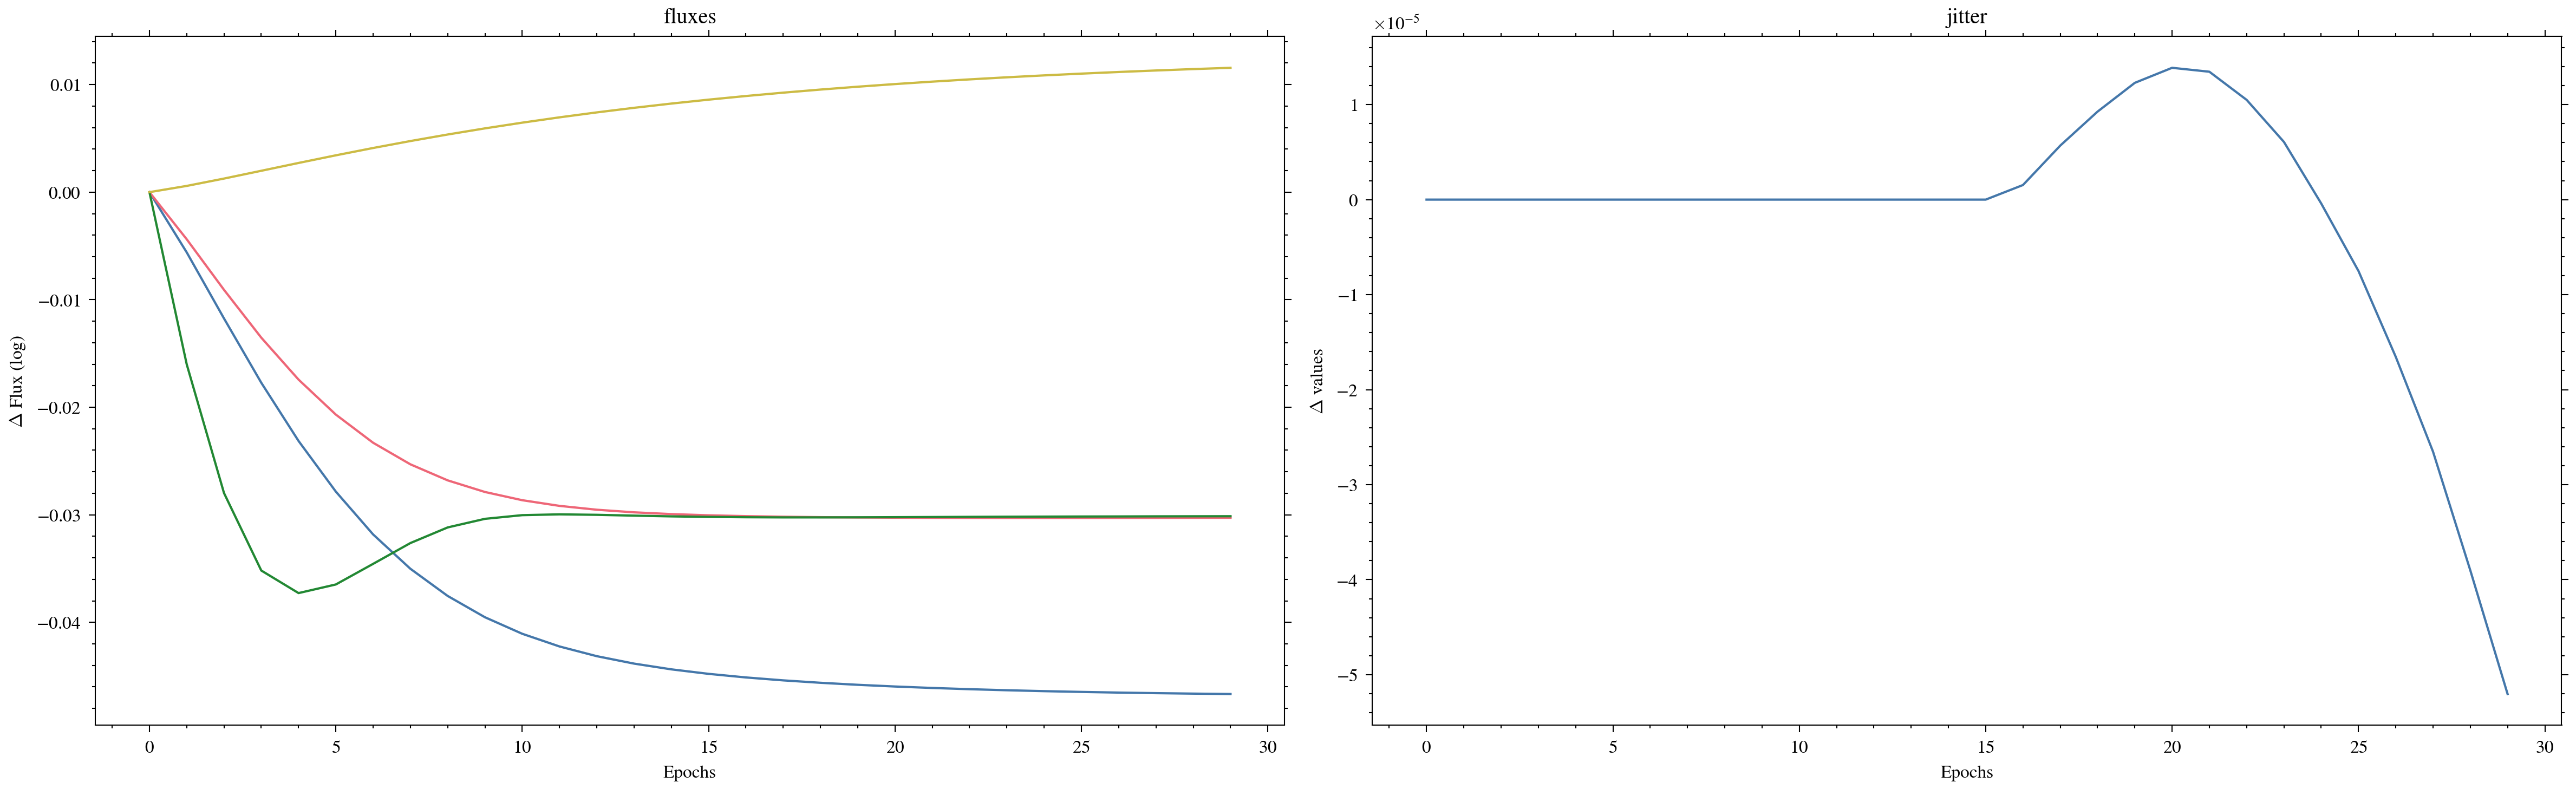

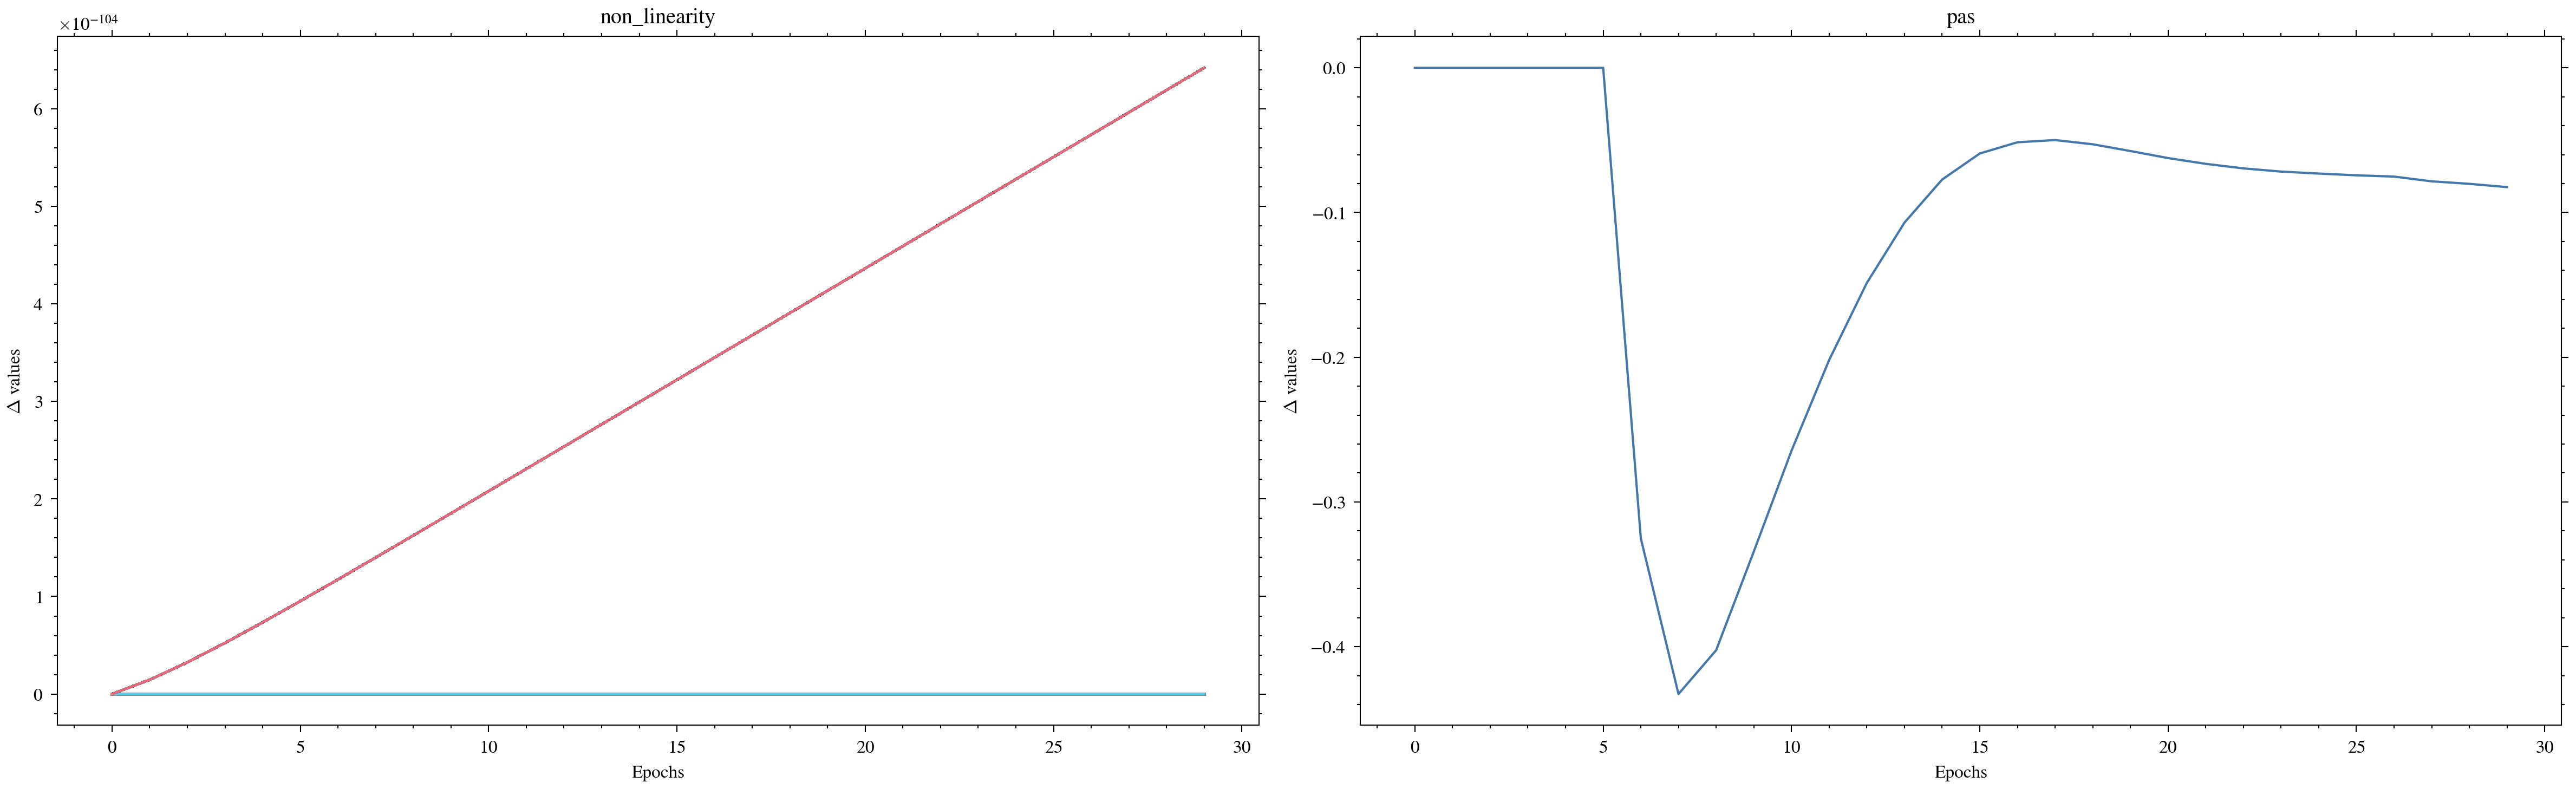

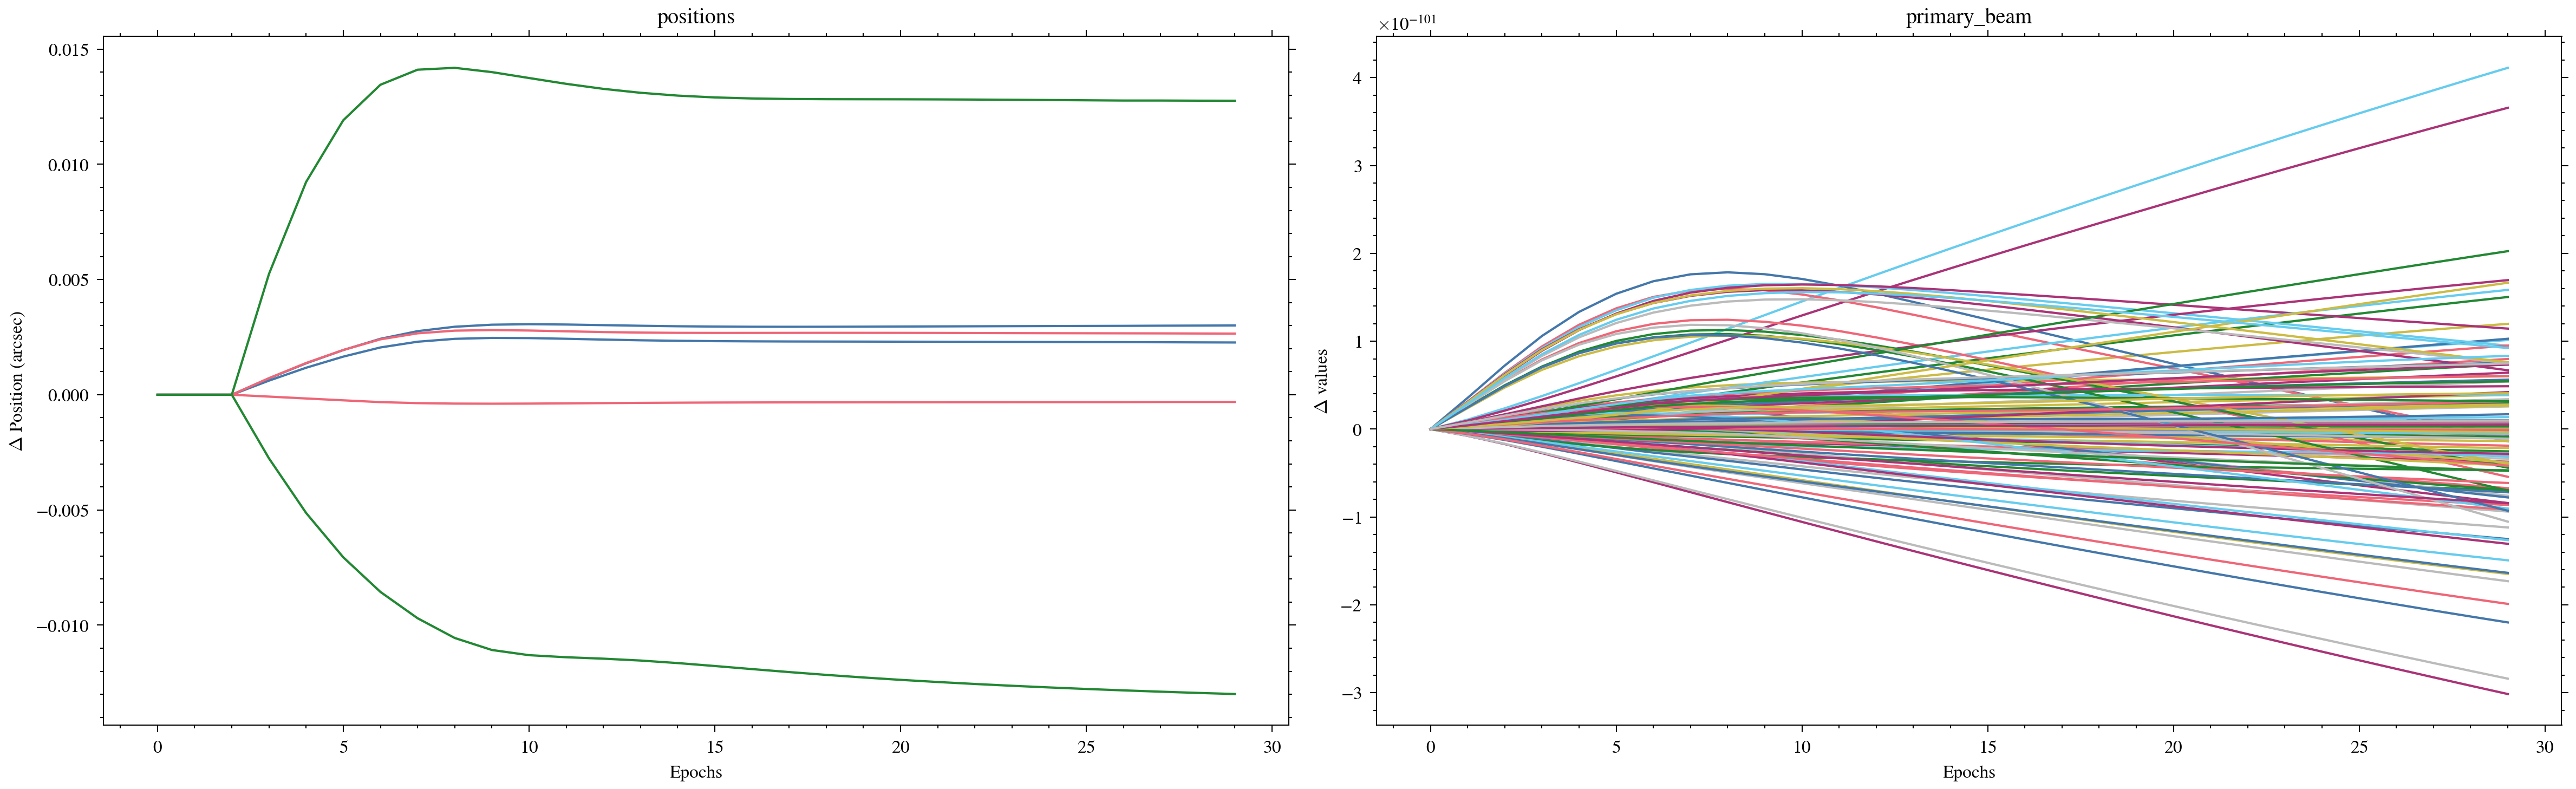

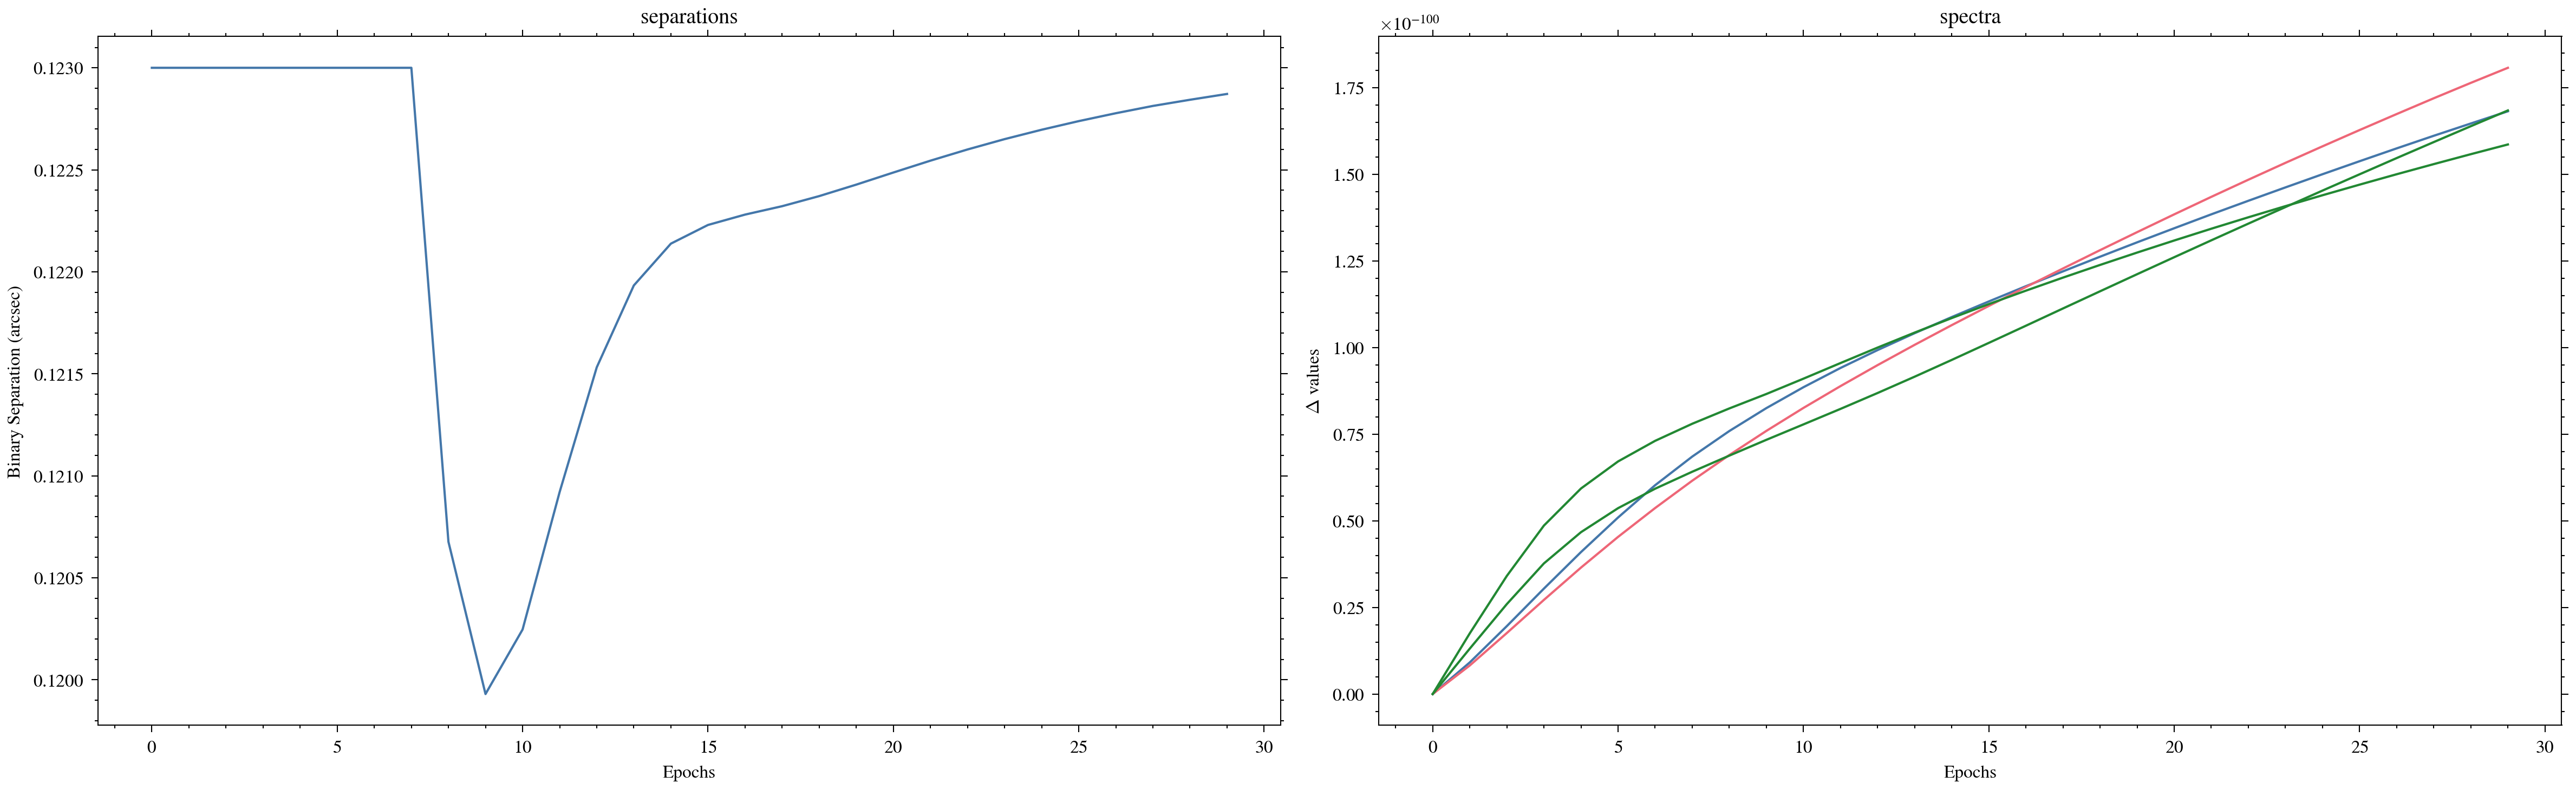

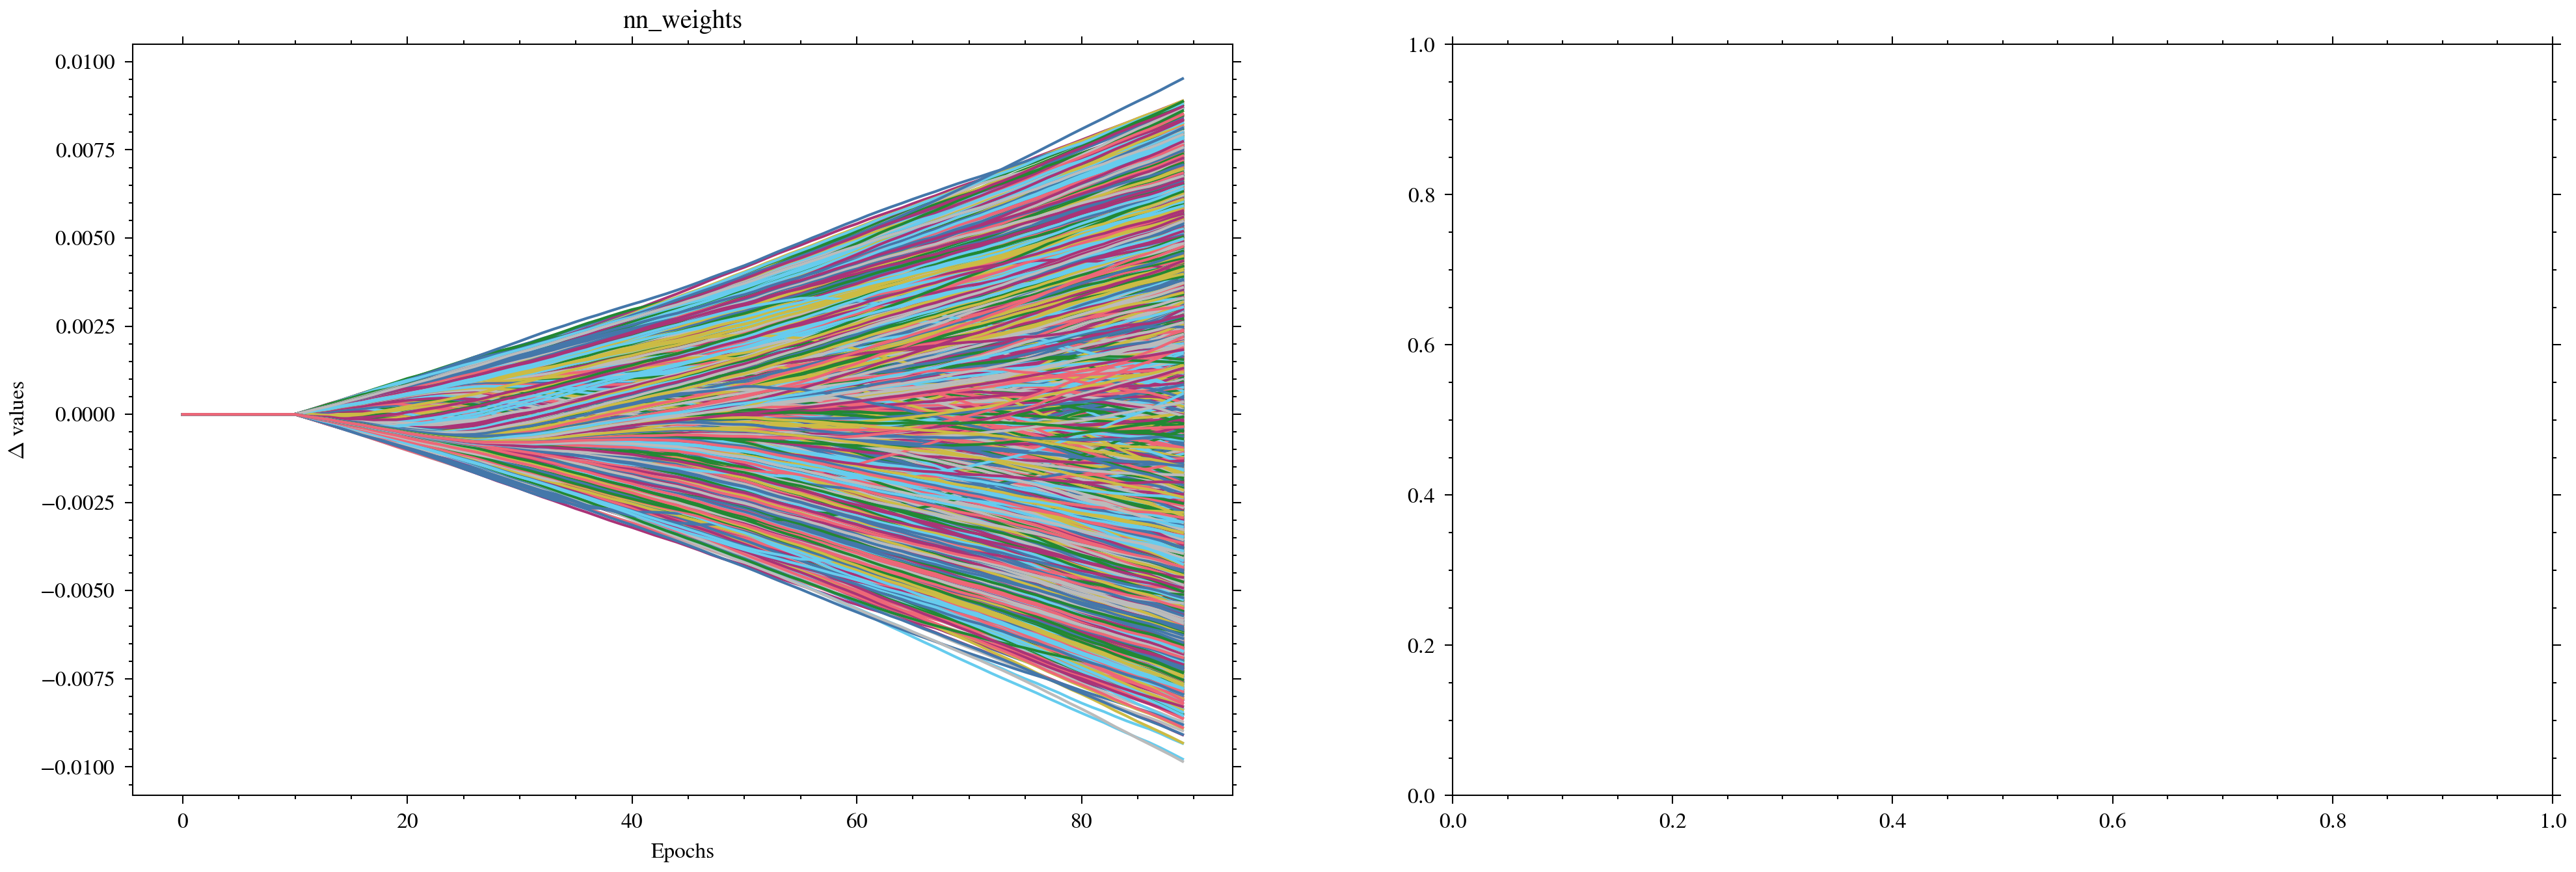

File 04481_001_02_03_4
Star HD-41094
Filter F480M
nints 760
ngroups 30



In [ ]:
exps = exposures

# amigo.plotting.plot_losses(result.losses[0], start=int(epochs * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=save_path)